In [1]:
# Description: Plot Figure 7 (decadal differences in shelf edge stratification and cross-isobath baroclinic geostrophic velocity)
# Author:      André Palóczy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy as ctpy
from cmocean.cm import thermal, haline, balance, curl, delta
from xarray import open_dataset


def near2(x, y, x0, y0):
    dr2 = (x - x0)**2 + (y - y0)**2
    return int(np.nanargmin(dr2))

## Define file paths.

In [3]:
head = "../proc/"

d = np.load(head + "isobath_200m.npz")
xi, yi, di = d["xi"], d["yi"], d["di"]
xseg0, yseg0 = np.loadtxt(head + "segment_latitudes_wei_etal2024.txt", unpack=True)
fseg = [near2(xi, yi, xseg0[i], yseg0[i]) for i in range(len(yseg0))]

# Clip start/end to fit segments.
xseg, yseg = xi[fseg], yi[fseg]
dibound = di[fseg]
txt_segs = ["AS", "CSS", "PSBS", "MS", "HS", "WSS", "NENSS"]

def annotate_segments(axs, dibound=dibound, txt_segs=txt_segs, ytxt=-100, add_segnames=True):
    for axi in axs:
        _ = [axi.axvline(x=dd, color="k", linestyle="--", linewidth=1.5, zorder=99998) for dd in dibound[1:-1]]
        if add_segnames:
            for i in range(len(txt_segs)):
                xtxt = 0.5*(dibound[i] + dibound[i+1])
                axi.text(xtxt, ytxt, txt_segs[i], ha="center", va="center", rotation=90, fontsize=14, color="m", fontweight="bold", zorder=99999)

f = "alongisob_decadal_WOA23_200m.nc"
ds = open_dataset(head + f)
x, z = ds["x"].values, ds["z"].values

getfattr: Removing leading '/' from absolute path names


In [4]:
figsize = (16, 10)

dCTmax = 0.6 # [degC]
dSAmax = 0.2 # [g/kg]
drhomax = 0.1 # [kg/m3]
dumax = 0.5 # [cm/s]

dCTmin = - dCTmax
dSAmin = - dSAmax
drhomin = - drhomax
dumin = - dumax

Tmin, Smin, rhomin = 6, 33, 25.4
Tmax, Smax, rhomax = 18, 35.7, 27.4
nlevs = 10
Tlevs = np.linspace(Tmin, Tmax, num=nlevs)
Slevs = np.linspace(Smin, Smax, num=nlevs)
rholevs = np.linspace(rhomin, rhomax, num=nlevs)
xtxt, ytxt = 1.07, 0.5
numtks = 5

Tmin, Smin, Dmin = 6, 33, 25.4
Tmax, Smax, Dmax = 18, 35.7, 27.4
Dmin0, Dmax0 = 23.2, 27.5

Tlevs = np.arange(Tmin, Tmax, 1)
Slevs = np.arange(Smin, Smax, 0.2)
Dlevs = np.arange(Dmin0, Dmax0, 0.4)

# Plot decadal anomalies (T, S, rho, ug_{bc}).
dec_str = ["1975-1984", "1985-1994", "1995-2004", "2005-2014", "2015-2022"]

dsanom = ds - ds.mean("t")
nrows = ds.sizes["t"]

## Plot Figure 7.

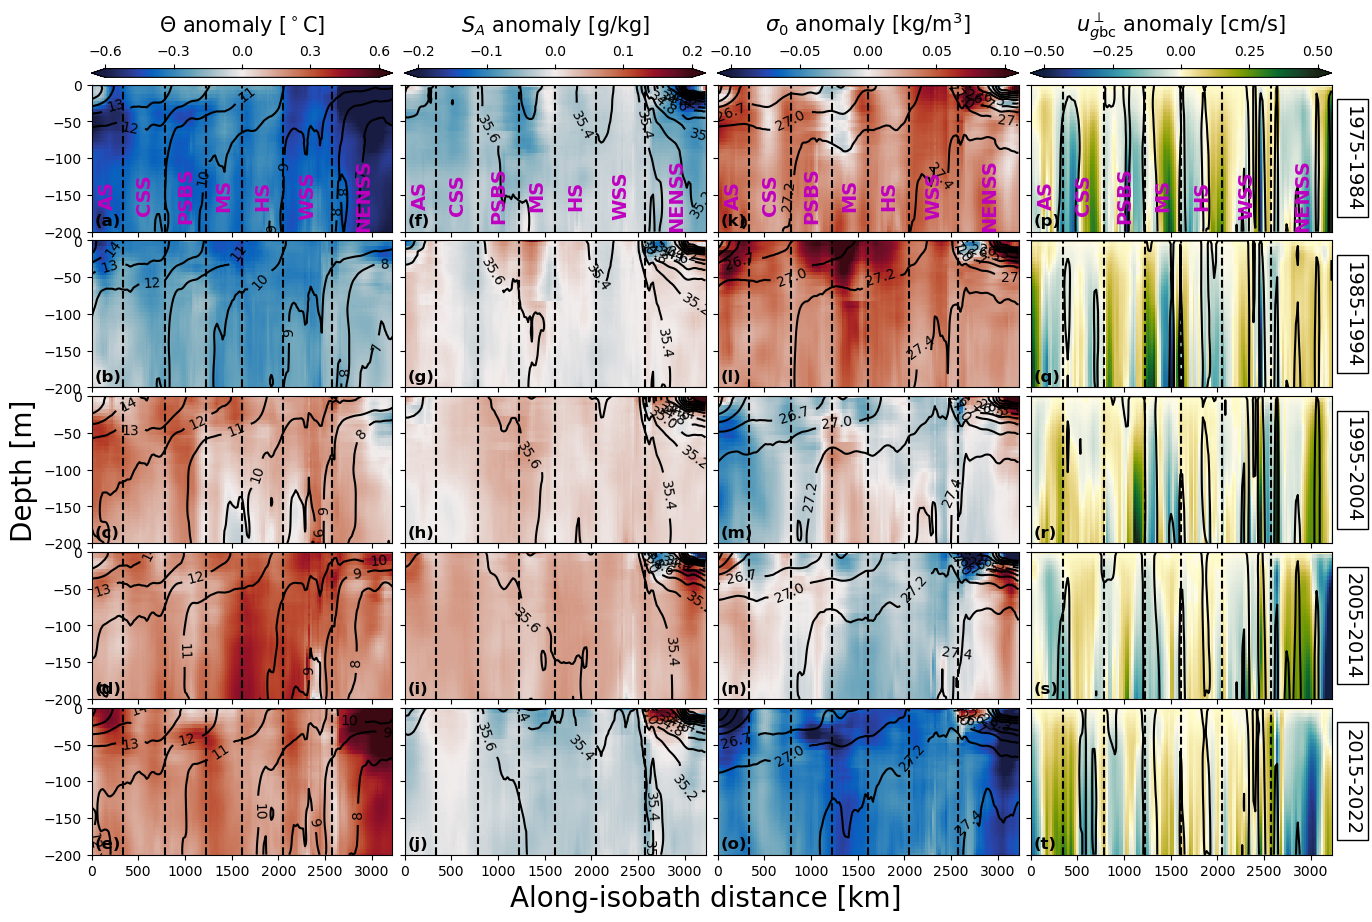

In [5]:
fig, ax = plt.subplots(nrows=nrows, ncols=4, sharex=True, sharey=True, figsize=figsize)

for n in range(nrows):
    axn = ax[n]
    axT, axS, axrho, axu = axn
    dsi = dsanom.isel(t=n)

    # Change from one decade to the next.
    dCT, dSA, drho, du = dsi["CT"].values, dsi["SA"].values, dsi["rho"].values, dsi["ug"].values
    maxdCT = np.nanmax(np.abs(dCT))
    maxdSA = np.nanmax(np.abs(dSA))
    maxdrho = np.nanmax(np.abs(drho))
    maxdu = np.nanmax(np.abs(du))

    csT = axT.pcolormesh(x, z, dCT, vmin=dCTmin, vmax=dCTmax, cmap=balance)
    csS = axS.pcolormesh(x, z, dSA, vmin=dSAmin, vmax=dSAmax, cmap=balance)
    csrho = axrho.pcolormesh(x, z, drho, vmin=drhomin, vmax=drhomax, cmap=balance)
    csu = axu.pcolormesh(x, z, du, vmin=dumin, vmax=dumax, cmap=delta)

    # Values at the current decade for contours.
    dsi0 = ds.isel(t=n)
    CTi, SAi, rhoi, ui = dsi0["CT"].values, dsi0["SA"].values, dsi0["rho"].values, dsi0["ug"].values
    ccT = axT.contour(x, z, CTi, levels=Tlevs, colors="k")
    ccS = axS.contour(x, z, SAi, levels=Slevs, colors="k")
    ccrho = axrho.contour(x, z, rhoi, levels=rholevs, colors="k")
    axu.contour(x, z, ui, levels=[0], colors="k")

    axT.clabel(ccT, fmt="%d")
    axS.clabel(ccS, fmt="%1.1f")
    axrho.clabel(ccrho, fmt="%1.1f")

    tstr = dec_str[n]
    axu.text(xtxt, ytxt, tstr, fontsize=14, transform=axu.transAxes, ha="center", va="center", rotation=-90, fontweight="normal", bbox=dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=1))
    if n==2:
        axT.set_ylabel(r"Depth [m]", fontsize=20)

axT.set_xlim(x[0], x[-1])
axT.set_ylim(z[-1], z[0])

# Add segment locations.
ytxt = -150
annotate_segments(ax[0], dibound=dibound, txt_segs=txt_segs, ytxt=ytxt, add_segnames=True)
_ = [annotate_segments(ax[n], dibound=dibound, txt_segs=txt_segs, ytxt=ytxt, add_segnames=False) for n in range(1, nrows)]

c = "k"
xlett, ylett = 0.01, 0.04
letters = list("abcdefghijklmnopqrst")
for axi, letter in zip(ax.T.ravel(), letters):
    axi.text(xlett, ylett, "(" + letter + ")", fontsize=12, fontweight="black", color=c, transform=axi.transAxes, zorder=9999)

cbxy = [0, 1.05, 1, 0.06]
kwcb = dict(orientation="horizontal", extend="both")
kwcbl = dict(fontsize=15, labelpad=10)

cax = ax[0][0].inset_axes(cbxy)
cb = fig.colorbar(csT, cax=cax, **kwcb)
cb.set_label(r"$\Theta$ anomaly [$^\circ$C]", **kwcbl)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top")
cb.ax.xaxis.set_ticks(np.linspace(dCTmin, dCTmax, num=numtks))

cax = ax[0][1].inset_axes(cbxy)
cb = fig.colorbar(csS, cax=cax, **kwcb)
cb.set_label(r"$S_A$ anomaly [g/kg]", **kwcbl)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top")
cb.ax.xaxis.set_ticks(np.linspace(dSAmin, dSAmax, num=numtks))

cax = ax[0][2].inset_axes(cbxy)
cb = fig.colorbar(csrho, cax=cax, **kwcb)
cb.set_label(r"$\sigma_0$ anomaly [kg/m$^3$]", **kwcbl)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top")
cb.ax.xaxis.set_ticks(np.linspace(drhomin, drhomax, num=numtks))

cax = ax[0][3].inset_axes(cbxy)
cb = fig.colorbar(csu, cax=cax, **kwcb)
cb.set_label(r"$u_{g\text{bc}}^\perp$ anomaly [cm/s]", **kwcbl)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top")
cb.ax.xaxis.set_ticks(np.linspace(dumin, dumax, num=numtks))

axS.set_xlabel(r"Along-isobath distance [km]", fontsize=20, x=1)
fig.subplots_adjust(hspace=0.06, wspace=0.04);

In [6]:
fig.savefig("fig7.png", bbox_inches="tight", dpi=200)